In [58]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [30]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train = train_df["clean_text"]
y_train = train_df["queue"]

X_test = test_df["clean_text"]
y_test = test_df["queue"]

In [31]:
y_train.value_counts()

queue
Technical Support                  6741
Product Support                    4200
Customer Service                   3411
IT Support                         2729
Billing and Payments               2234
Returns and Exchanges              1161
Service Outages and Maintenance     928
Sales and Pre-Sales                 710
Human Resources                     448
General Inquiry                     307
Name: count, dtype: int64

## LINEAR REGRESSION

In [32]:
queue_model_LR = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=70000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [33]:
queue_model_LR.fit(X_train, y_train)

C:\Users\Shivam\Documents\shivam\customer-support-copilot\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [34]:
queue_pred_LR = queue_model_LR.predict(X_test)

In [35]:
print(classification_report(y_test, queue_pred_LR, zero_division=0))

                                 precision    recall  f1-score   support

           Billing and Payments       0.70      0.71      0.71       554
               Customer Service       0.41      0.40      0.40       857
                General Inquiry       0.39      0.48      0.43        98
                Human Resources       0.44      0.52      0.47       128
                     IT Support       0.40      0.44      0.42       704
                Product Support       0.45      0.37      0.40      1052
          Returns and Exchanges       0.35      0.45      0.39       276
            Sales and Pre-Sales       0.32      0.58      0.41       208
Service Outages and Maintenance       0.48      0.69      0.57       220
              Technical Support       0.56      0.47      0.51      1621

                       accuracy                           0.47      5718
                      macro avg       0.45      0.51      0.47      5718
                   weighted avg       0.48      0

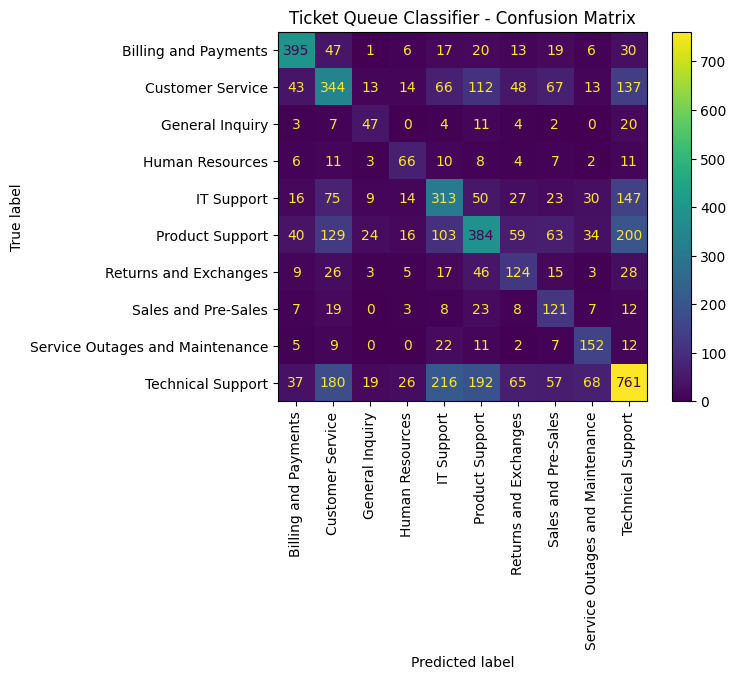

In [36]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, queue_pred_LR, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(xticks_rotation=90)
plt.title("Ticket Queue Classifier - Confusion Matrix")
plt.show()

## LinearSVC

In [38]:
queue_model_SVC = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [39]:
queue_model_SVC.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [41]:
queue_pred_SVC = queue_model_SVC.predict(X_test)

In [43]:
print(classification_report(y_test, queue_pred_SVC, zero_division=0))

                                 precision    recall  f1-score   support

           Billing and Payments       0.77      0.79      0.78       554
               Customer Service       0.52      0.57      0.54       857
                General Inquiry       0.70      0.49      0.57        98
                Human Resources       0.63      0.58      0.60       128
                     IT Support       0.55      0.53      0.54       704
                Product Support       0.54      0.51      0.52      1052
          Returns and Exchanges       0.51      0.51      0.51       276
            Sales and Pre-Sales       0.55      0.58      0.56       208
Service Outages and Maintenance       0.63      0.70      0.67       220
              Technical Support       0.64      0.63      0.63      1621

                       accuracy                           0.59      5718
                      macro avg       0.60      0.59      0.59      5718
                   weighted avg       0.59      0

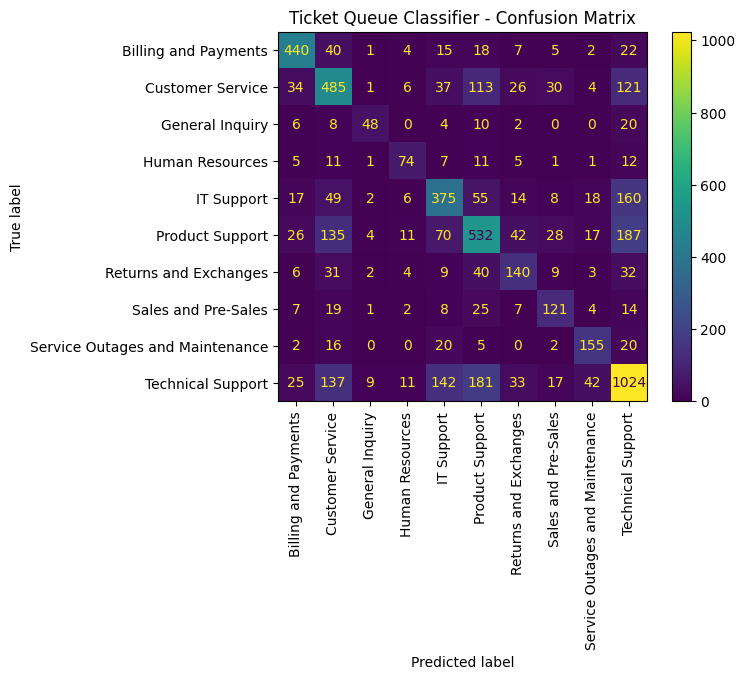

In [56]:
labels_SVC = sorted(y_test.unique())

cm_SVC = confusion_matrix(y_test, queue_pred_SVC, labels=labels_SVC)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_SVC,
    display_labels=labels_SVC
)

disp.plot(xticks_rotation=90)
plt.title("Ticket Queue Classifier - Confusion Matrix")
plt.show()

## Linear SVC with GridSearchCV

In [47]:
param_grid = {
    "tfidf__max_features": [30000, 50000],
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidf__min_df": [2, 3],
    "classifier__C": [0.1, 1, 10]
}

In [48]:
grid_search = GridSearchCV(
    estimator=queue_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

In [49]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'tfidf__max_features': [30000, 50000], 'tfidf__min_df': [2, 3], 'tfidf__ngram_range': [(1, ...), (1, ...), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [50]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 10, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best CV Score:
0.5890424062462299


In [51]:
best_queue_model = grid_search.best_estimator_

queue_pred = best_queue_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    queue_pred,
    zero_division=0
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.80      0.79      0.80       554
               Customer Service       0.54      0.59      0.56       857
                General Inquiry       0.77      0.45      0.57        98
                Human Resources       0.72      0.52      0.60       128
                     IT Support       0.56      0.54      0.55       704
                Product Support       0.54      0.56      0.55      1052
          Returns and Exchanges       0.60      0.47      0.53       276
            Sales and Pre-Sales       0.65      0.48      0.55       208
Service Outages and Maintenance       0.74      0.62      0.67       220
              Technical Support       0.63      0.68      0.65      1621

                       accuracy                           0.61      5718
                      macro avg       0.66      0.57      0.60      5718
                   weighted avg       0.62      0

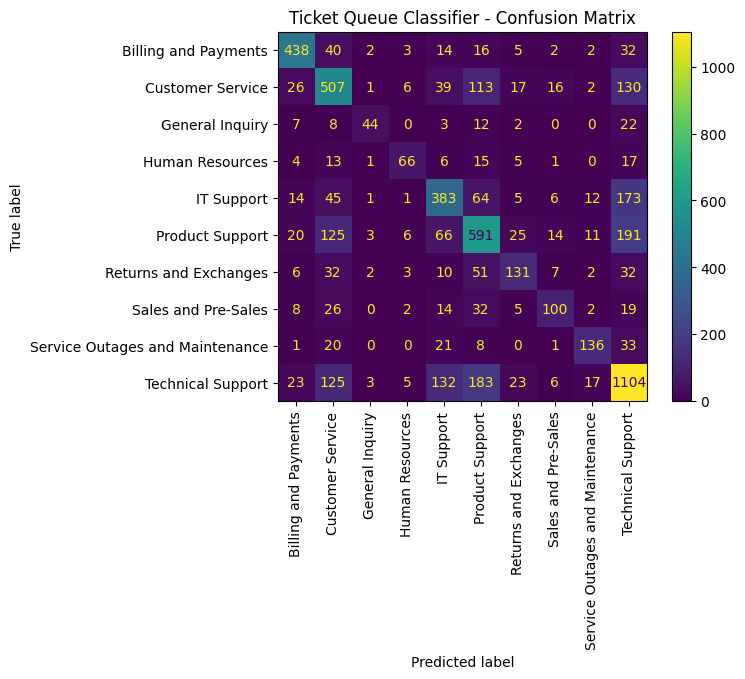

In [52]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, queue_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(xticks_rotation=90)
plt.title("Ticket Queue Classifier - Confusion Matrix")
plt.savefig("../reports/queue_confusion_matrix.png")
plt.show()

In [54]:
joblib.dump(best_queue_model, "../models/ticket_queue_baseline.pkl")

['../models/ticket_queue_baseline.pkl']

In [59]:
queue_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, queue_pred_LR),
        "macro_f1": f1_score(y_test, queue_pred_LR, average="macro"),
        "weighted_f1": f1_score(y_test, queue_pred_LR, average="weighted")
    },
    {
        "model": "LinearSVC",
        "accuracy": accuracy_score(y_test, queue_pred_SVC),
        "macro_f1": f1_score(y_test, queue_pred_SVC, average="macro"),
        "weighted_f1": f1_score(y_test, queue_pred_SVC, average="weighted")
    },
    {
        "model": "LinearSVC + GridSearchCV",
        "accuracy": accuracy_score(y_test, queue_pred),
        "macro_f1": f1_score(y_test, queue_pred, average="macro"),
        "weighted_f1": f1_score(y_test, queue_pred, average="weighted")
    }
])

queue_model_comparison

,model,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.473417,0.472920,0.473954
1,LinearSVC,0.593564,0.593359,0.593049
2,LinearSVC + GridSearchCV,0.612102,0.604281,0.611465


In [60]:
queue_model_comparison.to_csv(
    "../reports/queue_model_comparison.csv",
    index=False
)

In [55]:
queue_results = test_df.copy()
queue_results["actual_queue"] = y_test.values
queue_results["predicted_queue"] = queue_pred
queue_results["correct_queue"] = queue_results["actual_queue"] == queue_results["predicted_queue"]

wrong_queue = queue_results[queue_results["correct_queue"] == False]

wrong_queue.to_csv("../reports/wrong_queue_predictions.csv", index=False)

wrong_queue[["clean_text", "actual_queue", "predicted_queue", "type", "language"]].head(20)

,clean_text,actual_queue,predicted_queue,type,language
0,potential data breach in healthcare system the...,Human Resources,Technical Support,Incident,en
2,issue encountered assistance needed,Technical Support,Product Support,Problem,en
3,benötigte unterstützung bei datenintegration e...,General Inquiry,Product Support,Incident,de
6,enhanced security implement advanced security ...,Returns and Exchanges,Product Support,Change,de
8,gerät zur bildschirmaufnahme läuft unregelmäßi...,Product Support,IT Support,Incident,de
12,request for update and optimization of data an...,IT Support,Product Support,Change,de
16,"kontakten sie mich, um mehr über digitale stra...",Technical Support,Customer Service,Request,de
17,ungestorbener zugriff auf gesundheitsdienstlei...,Product Support,Technical Support,Problem,de
22,challenges in leadership for marketing agencie...,Sales and Pre-Sales,IT Support,Incident,de
28,datensicherheit im gesundheitswesen sehr geehr...,Product Support,Customer Service,Request,de


## Language-wise Evaluation

In [61]:
from sklearn.metrics import classification_report
import pandas as pd

queue_lang_rows = []

queue_results = test_df.copy()
queue_results["actual_queue"] = y_test.values
queue_results["predicted_queue"] = queue_pred

for lang in sorted(queue_results["language"].unique()):
    temp = queue_results[queue_results["language"] == lang]

    report = classification_report(
        temp["actual_queue"],
        temp["predicted_queue"],
        output_dict=True,
        zero_division=0
    )

    queue_lang_rows.append({
        "language": lang,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    })

queue_language_metrics = pd.DataFrame(queue_lang_rows)

queue_language_metrics.to_csv(
    "../reports/queue_language_metrics.csv",
    index=False
)

queue_language_metrics

,language,accuracy,macro_f1,weighted_f1
0,de,0.491722,0.457383,0.488996
1,en,0.700182,0.705804,0.700255


In [63]:
pd.crosstab(
    train_df["language"],
    train_df["queue"],
    normalize="index"
) * 100

queue,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
language,,,,,,,,,,
de,9.793552,15.407302,1.322079,1.861080,12.224143,17.888742,5.013729,3.010272,3.935727,29.543374
en,9.749923,14.544339,1.357778,2.032832,11.713716,18.725069,5.124271,3.175821,4.150046,29.426204


## Multilingual Improvement Experiment: Word + Character TF-IDF

In [65]:
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [66]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train = train_df["clean_text"]
y_train = train_df["queue"]

X_test = test_df["clean_text"]
y_test = test_df["queue"]

In [67]:
word_char_queue_model = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            max_features=70000,
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        ))
    ])),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

In [68]:
word_char_queue_model.fit(X_train, y_train)

word_char_queue_pred = word_char_queue_model.predict(X_test)

print(classification_report(
    y_test,
    word_char_queue_pred,
    zero_division=0
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.81      0.81      0.81       554
               Customer Service       0.53      0.58      0.55       857
                General Inquiry       0.67      0.48      0.56        98
                Human Resources       0.65      0.56      0.60       128
                     IT Support       0.55      0.54      0.54       704
                Product Support       0.54      0.52      0.53      1052
          Returns and Exchanges       0.54      0.54      0.54       276
            Sales and Pre-Sales       0.57      0.55      0.56       208
Service Outages and Maintenance       0.67      0.71      0.69       220
              Technical Support       0.65      0.65      0.65      1621

                       accuracy                           0.60      5718
                      macro avg       0.62      0.59      0.60      5718
                   weighted avg       0.61      0

In [69]:
language_rows = []

results = test_df.copy()
results["actual_queue"] = y_test.values
results["predicted_queue"] = word_char_queue_pred

for lang in sorted(results["language"].unique()):
    temp = results[results["language"] == lang]

    report = classification_report(
        temp["actual_queue"],
        temp["predicted_queue"],
        output_dict=True,
        zero_division=0
    )

    language_rows.append({
        "language": lang,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    })

word_char_language_metrics = pd.DataFrame(language_rows)

word_char_language_metrics

,language,accuracy,macro_f1,weighted_f1
0,de,0.502897,0.484206,0.502231
1,en,0.678680,0.685937,0.678300


In [70]:
import pandas as pd

queue_language_model_comparison = pd.DataFrame([
    {
        "model": "Word TF-IDF + LinearSVC/GridSearchCV",
        "language": "de",
        "accuracy": 0.491722,
        "macro_f1": 0.457383,
        "weighted_f1": 0.488996
    },
    {
        "model": "Word TF-IDF + LinearSVC/GridSearchCV",
        "language": "en",
        "accuracy": 0.700182,
        "macro_f1": 0.705804,
        "weighted_f1": 0.700255
    },
    {
        "model": "Word + Char TF-IDF + LinearSVC",
        "language": "de",
        "accuracy": 0.502897,
        "macro_f1": 0.484206,
        "weighted_f1": 0.502231
    },
    {
        "model": "Word + Char TF-IDF + LinearSVC",
        "language": "en",
        "accuracy": 0.678680,
        "macro_f1": 0.685937,
        "weighted_f1": 0.678300
    }
])

queue_language_model_comparison.to_csv(
    "../reports/queue_language_model_comparison.csv",
    index=False
)

queue_language_model_comparison

,model,language,accuracy,macro_f1,weighted_f1
0,Word TF-IDF + LinearSVC/GridSearchCV,de,0.491722,0.457383,0.488996
1,Word TF-IDF + LinearSVC/GridSearchCV,en,0.700182,0.705804,0.700255
2,Word + Char TF-IDF + LinearSVC,de,0.502897,0.484206,0.502231
3,Word + Char TF-IDF + LinearSVC,en,0.678680,0.685937,0.678300


## Experimenting with SGDClassifier

In [77]:
from sklearn.linear_model import SGDClassifier

In [78]:
sgd_queue_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("classifier", SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=1e-5,
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

sgd_queue_model.fit(X_train, y_train)

sgd_queue_pred = sgd_queue_model.predict(X_test)

print(classification_report(
    y_test,
    sgd_queue_pred,
    zero_division=0
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.75      0.80      0.77       554
               Customer Service       0.54      0.58      0.56       857
                General Inquiry       0.61      0.53      0.57        98
                Human Resources       0.69      0.56      0.62       128
                     IT Support       0.52      0.56      0.54       704
                Product Support       0.54      0.53      0.53      1052
          Returns and Exchanges       0.51      0.52      0.52       276
            Sales and Pre-Sales       0.54      0.51      0.52       208
Service Outages and Maintenance       0.64      0.70      0.67       220
              Technical Support       0.65      0.60      0.62      1621

                       accuracy                           0.59      5718
                      macro avg       0.60      0.59      0.59      5718
                   weighted avg       0.59      0

In [79]:
results = test_df.copy()
results["actual_queue"] = y_test.values
results["predicted_queue"] = sgd_queue_pred

for lang in sorted(results["language"].unique()):
    temp = results[results["language"] == lang]
    print("=" * 60)
    print("Language:", lang)
    print(classification_report(
        temp["actual_queue"],
        temp["predicted_queue"],
        zero_division=0
    ))

Language: de
                                 precision    recall  f1-score   support

           Billing and Payments       0.62      0.69      0.65       230
               Customer Service       0.42      0.49      0.45       343
                General Inquiry       0.38      0.31      0.34        39
                Human Resources       0.61      0.42      0.50        45
                     IT Support       0.41      0.44      0.42       289
                Product Support       0.38      0.39      0.39       420
          Returns and Exchanges       0.41      0.35      0.38       124
            Sales and Pre-Sales       0.48      0.33      0.39       109
Service Outages and Maintenance       0.52      0.57      0.54        97
              Technical Support       0.57      0.53      0.55       720

                       accuracy                           0.48      2416
                      macro avg       0.48      0.45      0.46      2416
                   weighted avg     

## Experimenting with MultinomialNB

In [80]:
from sklearn.naive_bayes import MultinomialNB

In [81]:
nb_queue_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", MultinomialNB(
        alpha=0.5
    ))
])

nb_queue_model.fit(X_train, y_train)

nb_queue_pred = nb_queue_model.predict(X_test)

print(classification_report(
    y_test,
    nb_queue_pred,
    zero_division=0
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.95      0.51      0.66       554
               Customer Service       0.28      0.45      0.34       857
                General Inquiry       0.00      0.00      0.00        98
                Human Resources       0.00      0.00      0.00       128
                     IT Support       0.78      0.04      0.08       704
                Product Support       0.39      0.24      0.30      1052
          Returns and Exchanges       1.00      0.01      0.03       276
            Sales and Pre-Sales       1.00      0.00      0.01       208
Service Outages and Maintenance       0.90      0.04      0.08       220
              Technical Support       0.39      0.81      0.53      1621

                       accuracy                           0.40      5718
                      macro avg       0.57      0.21      0.20      5718
                   weighted avg       0.53      0